# PANSS pseudo-real data: two-instrument G-estimation of total, direct, and indirect NNT

This notebook applies the **G-estimation strategy from the original simulation notebook** to one fixed PANSS-based pseudo-real dataset.

The analysis is restricted to the setting selected by the simulation study:

- The observed confounder $L$ is included in every fitted nuisance model.
- The unmeasured confounder $U$ is present in the data-generating mechanism but is hidden from the estimator.
- $Z_1$ is used as the instrument for treatment $A$.
- $Z_2$ is used as the instrument for the continuous mediator $M=\text{PANSS5}$.

The required adaptation is that the mediator is continuous rather than binary.

## 1. Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import statsmodels.api as sm

from scipy.special import expit
from scipy.optimize import root, root_scalar
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 6)

## 2. Generate one fixed PANSS-based pseudo-real dataset

The data-generating function is used once to create the dataset. After generation, the sample is treated as an observational dataset.

Although the generator creates $U$ and the true treatment probability $p_A$, neither variable is available to the estimation procedure.

In [2]:
def simulate_panss_based_data(N=5000, with_u=True, seed=42):
    rng = np.random.default_rng(seed)

    # --------------------------------------------------
    # Z1: Instrument for treatment assignment.
    # Clinical interpretation:
    # Z1 represents physician or medical center prescribing preference
    # for Paliperidone.
    #
    # IV assumptions:
    # 1. Z1 affects A, the probability of receiving Paliperidone.
    # 2. Z1 does not directly affect the mediator or the outcome,
    #    except through treatment A.
    # 3. Z1 is independent of the unmeasured confounder U.
    # --------------------------------------------------
    Z1 = rng.binomial(1, 0.5, N)

    # --------------------------------------------------
    # Z2: Instrument for the measured PANSS mediator.
    # Clinical interpretation:
    # Z2 represents PANSS rater calibration or site-level PANSS scoring tendency.
    # In a multi-center study, some raters/sites may systematically score PANSS
    # slightly lower or identify symptom improvement more readily.
    #
    # IV assumptions:
    # 1. Z2 affects the measured PANSS score at week 5.
    # 2. Z2 does not directly affect PSP improvement Y.
    # 3. Z2 is independent of the unmeasured confounder U.
    # 4. Z2 is not related to treatment assignment A.
    # --------------------------------------------------
    Z2 = rng.binomial(1, 0.5, N)

    # --------------------------------------------------
    # Baseline variables based on the PANSS paper
    # --------------------------------------------------
    age = np.clip(rng.normal(37, 11, N), 18, 65)
    male = rng.binomial(1, 0.65, N)
    bmi0 = np.clip(rng.normal(26, 6, N), 15, 42)
    panss0 = np.clip(rng.normal(47, 7.5, N), 31, 76)
    psp0 = np.clip(rng.normal(49, 15, N), 20, 90)
    sas0 = np.clip(rng.normal(3, 5, N), 0, 35)

    # --------------------------------------------------
    # L: Measured baseline severity.
    # Higher L means worse measured baseline condition:
    # - Higher baseline PANSS increases L.
    # - Lower baseline PSP increases L.
    # - Higher BMI and SAS slightly increase L.
    #
    # L is observed by the researcher and can be adjusted for.
    # --------------------------------------------------
    L = (
        0.50 * ((panss0 - 47) / 7.5)
        - 0.40 * ((psp0 - 49) / 15)
        + 0.15 * ((bmi0 - 26) / 6)
        + 0.15 * ((sas0 - 3) / 5)
    )

    # --------------------------------------------------
    # U: Unmeasured confounder.
    # Clinical interpretation:
    # U represents latent disease severity, cognition,
    # adherence, family support, or other unmeasured factors.
    #
    # U affects:
    # - A: probability of receiving treatment.
    # - panss5: symptom severity at week 5.
    # - psp6 / Y: social functioning improvement.
    #
    # U is generated in the simulation, but in the actual analysis
    # it should be treated as unobserved.
    # --------------------------------------------------
    U = rng.normal(0, 1, N)

    # --------------------------------------------------
    # Control whether unmeasured confounding exists.
    # with_u=True creates unmeasured confounding.
    # with_u=False removes the effect of U.
    # --------------------------------------------------
    if not with_u:
        U_effect_A = 0.0
        U_effect_PANSS = 0.0
        U_effect_PSP = 0.0
        U_effect_WG = 0.0
        U_effect_SAS = 0.0
    else:
        U_effect_A = 0.8
        U_effect_PANSS = 3.0
        U_effect_PSP = -3.0
        U_effect_WG = 0.01
        U_effect_SAS = 0.5

    # --------------------------------------------------
    # A: Treatment assignment.
    # A = 1 means the patient receives Paliperidone.
    # A = 0 means the patient receives placebo / no Paliperidone.
    #
    # In the original PANSS paper, treatment was randomized.
    # In this simulation, treatment assignment is observational:
    # A depends on Z1, measured severity L, and unmeasured confounding U.
    # --------------------------------------------------
    p_A = expit(
        -0.30
        + 1.20 * Z1
        + 0.60 * L
        + U_effect_A * U
    )
    A = rng.binomial(1, p_A)

    # --------------------------------------------------
    # panss5: PANSS score at week 5.
    # This is the main continuous mediator.
    #
    # In this simulation:
    # - A lowers PANSS, representing treatment benefit.
    # - Z2 lowers measured PANSS, representing rater/site scoring tendency.
    # - L and U increase PANSS, representing worse measured and unmeasured severity.
    # --------------------------------------------------
    panss5 = (
        37.5
        - 4.0 * A
        - 2.0 * Z2
        + 4.0 * L
        + U_effect_PANSS * U
        + rng.normal(0, 8.5, N)
    )
    panss5 = np.clip(panss5, 7, 90)

    # --------------------------------------------------
    # wg: Percent weight gain after treatment.
    # WG appears in the PANSS paper as a possible adverse-event variable.
    #
    # In the main project simulation, WG is not the central mediator.
    # We keep it to preserve part of the clinical story of the PANSS paper.
    # --------------------------------------------------
    wg = (
        -0.01
        + 0.03 * A
        + 0.01 * L
        + U_effect_WG * U
        + rng.normal(0, 0.045, N)
    )
    wg = np.clip(wg, -0.10, 0.40)

    # --------------------------------------------------
    # sas_max: Maximum SAS score after baseline.
    # SAS represents extrapyramidal / motor adverse events.
    #
    # In the PANSS paper, SAS was examined as a possible mediator,
    # but it was not statistically significant in the final mediation analysis.
    # Therefore, we keep SAS as a secondary clinical variable.
    # --------------------------------------------------
    sas_max = (
        2.8
        + 0.7 * A
        + 0.8 * L
        + U_effect_SAS * U
        + rng.normal(0, 5.5, N)
    )
    sas_max = np.clip(sas_max, 0, 35)

    # --------------------------------------------------
    # psp6: PSP score at week 6.
    # PSP measures personal and social functioning.
    # Higher PSP means better social functioning.
    #
    # Main mediation pathway:
    # A affects continuous PANSS at week 5,
    # and PANSS affects PSP at week 6.
    #
    # In this simulation:
    # - A has a direct effect on PSP.
    # - panss5 affects PSP as the main clinical mediator.
    # - WG and SAS are included as secondary clinical factors.
    # - L and U affect PSP, creating measured and unmeasured confounding.
    # --------------------------------------------------
    psp6 = (
        psp0
        + 5.0 * A
        - 0.85 * (panss5 - 37.5)
        + 35.0 * wg
        - 120.0 * (wg ** 2)
        - 0.10 * sas_max
        - 1.0 * L
        + U_effect_PSP * U
        + rng.normal(0, 10, N)
    )
    psp6 = np.clip(psp6, 1, 100)

    # --------------------------------------------------
    # Y: Binary outcome.
    # Y = 1 means clinically meaningful improvement in social functioning.
    # Y = 0 means no clinically meaningful improvement.
    #
    # We define improvement as an increase of at least 10 PSP points
    # from baseline to week 6.
    #
    # This binary outcome is needed because NNT, NNE, and EIN
    # are based on event probabilities.
    # --------------------------------------------------
    Y = ((psp6 - psp0) >= 10).astype(int)

    # --------------------------------------------------
    # Return the simulated dataset.
    #
    # Important:
    # U is returned only for simulation validation and for computing
    # the true effects. In the actual estimation step, U should be
    # removed or ignored to mimic a real observational study with
    # unmeasured confounding.
    # --------------------------------------------------
    df = pd.DataFrame({
        "Z1": Z1,
        "Z2": Z2,
        "L": L,
        "U": U,
        "A": A,
        "Y": Y,
        "age": age,
        "male": male,
        "bmi0": bmi0,
        "panss0": panss0,
        "panss5": panss5,
        "psp0": psp0,
        "psp6": psp6,
        "wg": wg,
        "sas0": sas0,
        "sas_max": sas_max,
        "p_A": p_A,
    })

    return df

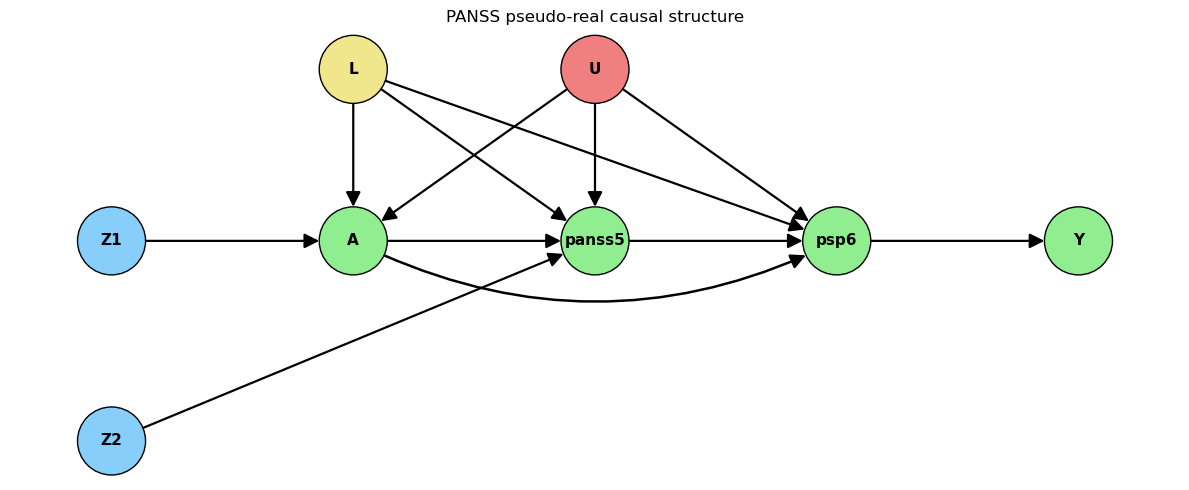

In [12]:
def draw_dag():
    graph = nx.DiGraph()

    regular_edges = [
        ("Z1", "A"),
        ("Z2", "panss5"),
        ("A", "panss5"),
        ("panss5", "psp6"),
        ("psp6", "Y"),
        ("L", "A"),
        ("L", "panss5"),
        ("L", "psp6"),
        ("U", "A"),
        ("U", "panss5"),
        ("U", "psp6"),
    ]
    curved_edges = [("A", "psp6")]
    graph.add_edges_from(regular_edges + curved_edges)

    pos = {
        "Z1": (0.0, 1.6),
        "Z2": (0.0, 0.2),
        "L": (2.0, 2.8),
        "A": (2.0, 1.6),
        "U": (4.0, 2.8),
        "panss5": (4.0, 1.6),
        "psp6": (6.0, 1.6),
        "Y": (8.0, 1.6),
    }

    node_colors = {
        "Z1": "lightskyblue",
        "Z2": "lightskyblue",
        "U": "lightcoral",
        "L": "khaki",
        "A": "lightgreen",
        "panss5": "lightgreen",
        "psp6": "lightgreen",
        "Y": "lightgreen",
    }

    plt.figure(figsize=(12, 5))
    nx.draw_networkx_nodes(
        graph,
        pos,
        node_color=[node_colors[node] for node in graph.nodes],
        node_size=2400,
        edgecolors="black",
    )
    nx.draw_networkx_labels(graph, pos, font_size=11, font_weight="bold")
    nx.draw_networkx_edges(
        graph,
        pos,
        edgelist=regular_edges,
        arrows=True,
        arrowsize=22,
        width=1.6,
        node_size=2400,
    )
    nx.draw_networkx_edges(
        graph,
        pos,
        edgelist=curved_edges,
        arrows=True,
        arrowsize=22,
        width=1.8,
        node_size=2400,
        connectionstyle="arc3,rad=0.25",
    )
    plt.title("PANSS pseudo-real causal structure")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


draw_dag()


## 3. Create the analysis sample

In [3]:
SEED = 42
N = 10_000

df_full = simulate_panss_based_data(
    N=N,
    with_u=True,
    seed=SEED,
)

analysis_columns = ["A", "panss5", "Y", "L", "Z1", "Z2"]
df_analysis = df_full[analysis_columns].copy()

print(f"Sample size: {len(df_analysis):,}")
display(df_analysis.head())

Sample size: 10,000


,A,panss5,Y,L,Z1,Z2
0,1,33.109985,0,-0.074024,1,1
1,1,23.781240,0,0.712833,0,1
2,1,32.176976,0,-0.141939,1,0
3,0,27.099708,0,0.475444,1,0
4,0,41.580047,0,0.194137,0,0


## 4. Descriptive checks

These summaries describe the fixed pseudo-real sample. They are not causal estimates.

In [4]:
print("Overall means")
display(df_analysis.mean().to_frame("mean"))

print("\nObserved outcome and mediator by treatment")
display(
    df_full.groupby("A")[["panss0", "panss5", "psp0", "psp6", "Y"]].mean()
)

print("\nInstrument Z1 and treatment")
display(df_analysis.groupby("Z1")[["A", "Y"]].mean())

print("\nInstrument Z2 and mediator")
display(df_analysis.groupby("Z2")[["A", "panss5", "Y"]].mean())

Overall means


,mean
A,0.565200
panss5,34.203892
Y,0.367100
L,0.016251
Z1,0.498500
Z2,0.507700



Observed outcome and mediator by treatment


,panss0,panss5,psp0,psp6,Y
A,,,,,
0,46.148233,34.846600,50.855568,53.101669,0.290478
1,47.654498,33.709467,47.976551,55.341643,0.426044



Instrument Z1 and treatment


,A,Y
Z1,,
0,0.439880,0.331805
1,0.691274,0.402608



Instrument Z2 and mediator


,A,panss5,Y
Z2,,,
0,0.574040,35.226784,0.347146
1,0.556628,33.212028,0.386449


## 5. Causal estimands

Let $M(a)$ denote the PANSS mediator under treatment level $a$, and let $Y(a,m)$ denote the binary PSP-improvement outcome under treatment $a$ and mediator value $m$.

The three risks required for the mediation decomposition are

$$
R_{11}=\mathbb{E}\!\left[Y\{1,M(1)\}\right],
\qquad
R_{00}=\mathbb{E}\!\left[Y\{0,M(0)\}\right],
\qquad
R_{10}=\mathbb{E}\!\left[Y\{1,M(0)\}\right].
$$

The risk-difference effects are

$$
\begin{aligned}
RD_{\mathrm{total}} &= R_{11}-R_{00},\\
RD_{\mathrm{direct}} &= R_{10}-R_{00},\\
RD_{\mathrm{indirect}} &= R_{11}-R_{10}.
\end{aligned}
$$

Therefore,

$$
RD_{\mathrm{total}}
=
RD_{\mathrm{direct}}
+
RD_{\mathrm{indirect}}.
$$

For each component $k$, the signed NNT is

$$
NNT_k=\frac{1}{RD_k}.
$$

In [5]:
def nnt_from_rd(rd, tol=1e-10):
    """Return the signed NNT used in the original simulation notebook."""
    if pd.isna(rd):
        return np.nan
    if abs(float(rd)) < tol:
        return np.inf
    return 1.0 / float(rd)


def add_nnt_cols(results, tol=1e-10):
    output = dict(results)
    for component in ["total", "direct", "indirect"]:
        rd_key = f"{component}_rd"
        if rd_key in output:
            output[f"{component}_nnt"] = nnt_from_rd(
                output[rd_key],
                tol=tol,
            )
    return output

## 6. Instrument relevance adjusted for $L$

For the treatment instrument,

$$
A=\gamma_0+\gamma_1 Z_1+\gamma_L L+\varepsilon_A.
$$

For the mediator instrument,

$$
M=\delta_0+\delta_1 Z_2+\delta_A A+\delta_L L+\varepsilon_M.
$$

Large squared robust $t$-statistics support relevance. They do not establish instrument independence or the exclusion restriction.

In [6]:
def instrument_relevance_table(df):
    fit_z1 = sm.OLS(
        df["A"],
        sm.add_constant(df[["Z1", "L"]], has_constant="add"),
    ).fit(cov_type="HC1")

    fit_z2 = sm.OLS(
        df["panss5"],
        sm.add_constant(df[["Z2", "A", "L"]], has_constant="add"),
    ).fit(cov_type="HC1")

    return pd.DataFrame([
        {
            "instrument": "Z1 for A",
            "coefficient": fit_z1.params["Z1"],
            "robust_se": fit_z1.bse["Z1"],
            "p_value": fit_z1.pvalues["Z1"],
            "robust_t_squared": fit_z1.tvalues["Z1"] ** 2,
        },
        {
            "instrument": "Z2 for panss5",
            "coefficient": fit_z2.params["Z2"],
            "robust_se": fit_z2.bse["Z2"],
            "p_value": fit_z2.pvalues["Z2"],
            "robust_t_squared": fit_z2.tvalues["Z2"] ** 2,
        },
    ])


relevance_results = instrument_relevance_table(df_analysis)
display(relevance_results)

,instrument,coefficient,robust_se,p_value,robust_t_squared
0,Z1 for A,0.252223,0.009475,3.970827e-156,708.630870
1,Z2 for panss5,-2.024778,0.180191,2.688351e-29,126.266564


## 7. G-estimation with a continuous mediator

### 7.1 Mediator blip

We use the additive structural model

$$
M(a)=M(0)+\theta a.
$$

For an observed subject, the mediator blipped down to the no-treatment state is

$$
H_M(\theta)=M-\theta A.
$$

The causal parameter $\theta$ is selected so that the blipped-down mediator is orthogonal to the treatment instrument:

$$
\sum_{i=1}^{n}
(Z_{1i}-\bar{Z}_1)
H_{M,i}(\theta)
=0.
$$

As in the original simulation notebook, a nuisance association model that includes $L$ is fitted first:

$$
\mathbb{E}(M\mid A,Z_1,Z_2,L).
$$

For the continuous mediator, the individual counterfactual mediator values are constructed by preserving each subject's fitted residual:

$$
\widehat{M}_i(0)=M_i-\widehat{\theta} A_i,
$$

$$
\widehat{M}_i(1)=M_i+\widehat{\theta}(1-A_i).
$$

### 7.2 Outcome blips

A logistic association model is fitted:

$$
\operatorname{logit}
\Pr(Y=1\mid A,M,Z_1,Z_2,L)
=
\eta(A,M,Z_1,Z_2,L).
$$

The blipped-down outcome risk under $A=0$ and $M=0$ is

$$
H_Y(\psi_A,\psi_M)
=
\operatorname{expit}
\left\{
\eta-\psi_A A-\psi_M M
\right\}.
$$

The two causal blip parameters solve

$$
\sum_{i=1}^{n}
(Z_{1i}-\bar{Z}_1)
H_{Y,i}(\psi_A,\psi_M)
=0,
$$

$$
\sum_{i=1}^{n}
(Z_{2i}-\bar{Z}_2)
H_{Y,i}(\psi_A,\psi_M)
=0.
$$

### 7.3 Counterfactual risks

For arbitrary $a$ and $m$,

$$
\widehat{p}_i(a,m)
=
\operatorname{expit}
\left[
\widehat{\eta}_i
+
\widehat{\psi}_A(a-A_i)
+
\widehat{\psi}_M(m-M_i)
\right].
$$

The standardized risks are

$$
\widehat{R}_{11}
=
\frac{1}{n}\sum_{i=1}^{n}
\widehat{p}_i\{1,\widehat{M}_i(1)\},
$$

$$
\widehat{R}_{00}
=
\frac{1}{n}\sum_{i=1}^{n}
\widehat{p}_i\{0,\widehat{M}_i(0)\},
$$

$$
\widehat{R}_{10}
=
\frac{1}{n}\sum_{i=1}^{n}
\widehat{p}_i\{1,\widehat{M}_i(0)\}.
$$

This is the continuous-mediator adaptation of the two-instrument G-estimation prototype in the original simulation notebook.

In [7]:
def _fit_logit(y, X):
    X_design = sm.add_constant(X, has_constant="add")
    return sm.GLM(
        y,
        X_design,
        family=sm.families.Binomial(),
    ).fit()


def _solve_one_dim(fun, x0=0.0):
    """Use the bracket-then-root strategy from the simulation notebook."""
    grid = np.linspace(-20.0, 20.0, 161)
    values = [fun(value) for value in grid]

    for lo, hi, f_lo, f_hi in zip(
        grid[:-1],
        grid[1:],
        values[:-1],
        values[1:],
    ):
        if (
            np.isfinite(f_lo)
            and np.isfinite(f_hi)
            and f_lo * f_hi <= 0
        ):
            return float(root_scalar(fun, bracket=[lo, hi]).root)

    solution = root(
        lambda parameter: [fun(parameter[0])],
        [x0],
    )

    if not solution.success:
        raise RuntimeError(
            "The one-dimensional G-estimation equation did not converge."
        )

    return float(solution.x[0])


def _solve_outcome_blips(equations, association_start):
    """
    Solve the two nonlinear G-estimation moment equations.

    Multiple starting values are used because logistic moment equations can
    also possess numerically saturated solutions.
    """
    starts = [
        np.array([0.50, -0.05]),
        np.array([1.00, -0.10]),
        np.array([0.25, -0.02]),
        np.asarray(association_start, dtype=float),
        np.array([0.00, 0.00]),
    ]

    candidates = []

    for start in starts:
        solution = root(equations, x0=start)
        moment_norm = float(np.linalg.norm(equations(solution.x)))

        psi_a, psi_m = solution.x
        plausible_scale = abs(psi_a) <= 8.0 and abs(psi_m) <= 1.0

        if (
            solution.success
            and np.all(np.isfinite(solution.x))
            and moment_norm < 1e-8
            and plausible_scale
        ):
            candidates.append(solution)

    if not candidates:
        raise RuntimeError(
            "The outcome G-estimation equations did not converge "
            "to a finite, non-saturated solution."
        )

    target = np.asarray(association_start, dtype=float)
    return min(
        candidates,
        key=lambda solution: np.linalg.norm(solution.x - target),
    )


def g_estimation_continuous_mediator(df):
    """
    Two-instrument G-estimation adapted from the original simulation notebook.

    L is included in every nuisance association model.
    U is never used.
    """
    A = df["A"].to_numpy(dtype=float)
    M = df["panss5"].to_numpy(dtype=float)
    Z1 = df["Z1"].to_numpy(dtype=float)
    Z2 = df["Z2"].to_numpy(dtype=float)

    z1_centered = Z1 - Z1.mean()
    z2_centered = Z2 - Z2.mean()

    # 1. Mediator blip: estimate theta, the treatment effect on PANSS5.
    mediator_columns = ["A", "Z1", "Z2", "L"]
    X_mediator = sm.add_constant(
        df[mediator_columns],
        has_constant="add",
    )

    mediator_association = sm.OLS(
        df["panss5"],
        X_mediator,
    ).fit()

    mediator_linear_predictor = np.asarray(
        X_mediator @ mediator_association.params
    )

    def mediator_moment(theta):
        mediator_blipped_to_zero = (
            mediator_linear_predictor
            - theta * A
        )
        return float(
            np.mean(z1_centered * mediator_blipped_to_zero)
        )

    theta_initial = float(
        np.sum(z1_centered * mediator_linear_predictor)
        / np.sum(z1_centered * A)
    )

    theta = _solve_one_dim(
        mediator_moment,
        x0=theta_initial,
    )

    mediator_residual = M - mediator_linear_predictor

    M0 = (
        mediator_linear_predictor
        - theta * A
        + mediator_residual
    )

    M1 = (
        mediator_linear_predictor
        + theta * (1.0 - A)
        + mediator_residual
    )

    # 2. Outcome blips: estimate the direct treatment and mediator effects.
    outcome_columns = ["A", "panss5", "Z1", "Z2", "L"]
    outcome_association = _fit_logit(
        df["Y"],
        df[outcome_columns],
    )

    X_outcome = sm.add_constant(
        df[outcome_columns],
        has_constant="add",
    )

    outcome_linear_predictor = np.asarray(
        X_outcome @ outcome_association.params
    )

    def outcome_moments(parameters):
        psi_a, psi_m = parameters

        outcome_blipped_to_zero = expit(
            outcome_linear_predictor
            - psi_a * A
            - psi_m * M
        )

        return np.array([
            np.mean(z1_centered * outcome_blipped_to_zero),
            np.mean(z2_centered * outcome_blipped_to_zero),
        ])

    association_start = np.array([
        outcome_association.params["A"],
        outcome_association.params["panss5"],
    ])

    outcome_solution = _solve_outcome_blips(
        outcome_moments,
        association_start=association_start,
    )

    psi_a, psi_m = map(float, outcome_solution.x)

    # 3. Standardized counterfactual risks.
    def counterfactual_probability(a, mediator_value):
        return expit(
            outcome_linear_predictor
            + psi_a * (a - A)
            + psi_m * (mediator_value - M)
        )

    risk_1_M1 = float(
        np.mean(counterfactual_probability(1.0, M1))
    )
    risk_0_M0 = float(
        np.mean(counterfactual_probability(0.0, M0))
    )
    risk_1_M0 = float(
        np.mean(counterfactual_probability(1.0, M0))
    )

    results = add_nnt_cols({
        "risk_Y_1_M1": risk_1_M1,
        "risk_Y_0_M0": risk_0_M0,
        "risk_Y_1_M0": risk_1_M0,
        "total_rd": risk_1_M1 - risk_0_M0,
        "direct_rd": risk_1_M0 - risk_0_M0,
        "indirect_rd": risk_1_M1 - risk_1_M0,
        "theta_A_to_M": theta,
        "psi_A_direct_log_odds_blip": psi_a,
        "psi_M_log_odds_blip": psi_m,
        "mediator_moment": mediator_moment(theta),
        "outcome_moment_Z1": outcome_moments([psi_a, psi_m])[0],
        "outcome_moment_Z2": outcome_moments([psi_a, psi_m])[1],
        "outcome_root_success": bool(outcome_solution.success),
    })

    fitted_objects = {
        "mediator_association": mediator_association,
        "outcome_association": outcome_association,
        "M0": M0,
        "M1": M1,
    }

    return results, fitted_objects

## 8. Run the G-estimator

In [8]:
g_results, g_models = g_estimation_continuous_mediator(df_analysis)

parameter_columns = [
    "theta_A_to_M",
    "psi_A_direct_log_odds_blip",
    "psi_M_log_odds_blip",
    "mediator_moment",
    "outcome_moment_Z1",
    "outcome_moment_Z2",
    "outcome_root_success",
]

display(
    pd.DataFrame(
        [g_results],
        index=["Two-IV G-estimation adjusted for L"],
    )[parameter_columns]
)

,theta_A_to_M,psi_A_direct_log_odds_blip,psi_M_log_odds_blip,mediator_moment,outcome_moment_Z1,outcome_moment_Z2,outcome_root_success
Two-IV G-estimation adjusted for L,-4.732932,1.104247,-0.131248,1.136868e-17,1.231939e-14,-1.588507e-14,True


### Interpretation of the estimated blip parameters

- $\widehat{\theta}$ is the estimated causal change in PANSS5 produced by treatment. A negative value means that treatment lowers PANSS.
- $\widehat{\psi}_A$ is the direct treatment blip in the logistic structural model.
- $\widehat{\psi}_M$ is the PANSS mediator blip in the logistic structural model.
- The three estimated moments should be approximately zero, confirming that the G-estimation equations were solved numerically.

The $\psi$ parameters are log-odds blip parameters. They are not themselves risk differences. The risk differences are obtained through counterfactual standardization.

## 9. Final total, direct, and indirect NNT results

In [9]:
result_columns = [
    "risk_Y_1_M1",
    "risk_Y_0_M0",
    "risk_Y_1_M0",
    "total_rd",
    "direct_rd",
    "indirect_rd",
    "total_nnt",
    "direct_nnt",
    "indirect_nnt",
]

final_results = pd.DataFrame(
    [g_results],
    index=["Two-IV G-estimation adjusted for L"],
)[result_columns]

final_results["decomposition_error"] = (
    final_results["total_rd"]
    - final_results["direct_rd"]
    - final_results["indirect_rd"]
)

display(final_results)

assert np.isclose(
    final_results.iloc[0]["total_rd"],
    final_results.iloc[0]["direct_rd"]
    + final_results.iloc[0]["indirect_rd"],
    atol=1e-10,
)

,risk_Y_1_M1,risk_Y_0_M0,risk_Y_1_M0,total_rd,direct_rd,indirect_rd,total_nnt,direct_nnt,indirect_nnt,decomposition_error
Two-IV G-estimation adjusted for L,0.49729,0.222411,0.389556,0.274879,0.167146,0.107733,3.637961,5.9828,9.282169,0.0


The final estimates are calculated from three standardized counterfactual risks:

$$
\widehat{R}_{11}
=
\widehat{\mathbb{E}}\!\left[Y\{1,M(1)\}\right],
$$

$$
\widehat{R}_{00}
=
\widehat{\mathbb{E}}\!\left[Y\{0,M(0)\}\right],
$$

$$
\widehat{R}_{10}
=
\widehat{\mathbb{E}}\!\left[Y\{1,M(0)\}\right].
$$

The total risk difference is

$$
\widehat{RD}_{\mathrm{total}}
=
\widehat{R}_{11}
-
\widehat{R}_{00}.
$$

The direct risk difference is

$$
\widehat{RD}_{\mathrm{direct}}
=
\widehat{R}_{10}
-
\widehat{R}_{00}.
$$

The indirect risk difference through PANSS is

$$
\widehat{RD}_{\mathrm{indirect}}
=
\widehat{R}_{11}
-
\widehat{R}_{10}.
$$

The risk differences satisfy the additive decomposition

$$
\widehat{RD}_{\mathrm{total}}
=
\widehat{RD}_{\mathrm{direct}}
+
\widehat{RD}_{\mathrm{indirect}}.
$$

For each component $k$, the signed NNT is

$$
\widehat{NNT}_k
=
\frac{1}{\widehat{RD}_k}.
$$

$$
\frac{1}{\widehat{NNT}_{\mathrm{total}}}
=
\frac{1}{\widehat{NNT}_{\mathrm{direct}}}
+
\frac{1}{\widehat{NNT}_{\mathrm{indirect}}}.
$$

## 10. Bootstrap confidence intervals

The complete G-estimation procedure should be repeated within every bootstrap sample. Confidence intervals are first calculated for the risk differences.

If a risk-difference interval crosses zero, its reciprocal does not form one finite continuous NNT interval.

In [10]:
def bootstrap_g_estimation_rd(
    df,
    B=1000,
    seed=2026,
):
    rng = np.random.default_rng(seed)
    rows = []
    failures = 0

    for _ in range(B):
        indices = rng.integers(
            0,
            len(df),
            size=len(df),
        )
        bootstrap_sample = (
            df.iloc[indices]
              .reset_index(drop=True)
        )

        try:
            estimate, _ = g_estimation_continuous_mediator(
                bootstrap_sample
            )

            rows.append({
                "total_rd": estimate["total_rd"],
                "direct_rd": estimate["direct_rd"],
                "indirect_rd": estimate["indirect_rd"],
            })
        except Exception:
            failures += 1

    bootstrap_results = (
        pd.DataFrame(rows)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    intervals = pd.DataFrame({
        "bootstrap_mean": bootstrap_results.mean(),
        "ci_2.5%": bootstrap_results.quantile(0.025),
        "ci_97.5%": bootstrap_results.quantile(0.975),
    })

    intervals["successful_bootstraps"] = len(
        bootstrap_results
    )
    intervals["failed_bootstraps"] = failures

    return intervals, bootstrap_results


In [11]:
g_ci, g_boot = bootstrap_g_estimation_rd(
    df_analysis,
    B=100,
    seed=42,
)
display(g_ci)

,bootstrap_mean,ci_2.5%,ci_97.5%,successful_bootstraps,failed_bootstraps
total_rd,0.279516,0.203881,0.340607,100,0
direct_rd,0.171376,0.078830,0.242657,100,0
indirect_rd,0.108140,0.060981,0.158744,100,0


## 11. Results

The bootstrap analysis indicates a positive and statistically supported total treatment effect on the probability of improvement. The estimated total risk difference was 0.280 (95% CI: 0.204–0.341), corresponding to an NNT of approximately 3.6. This total effect was decomposed into a direct risk difference of 0.171 (95% CI: 0.079–0.243; NNT ≈ 5.8) and an indirect risk difference through PANSS of 0.108 (95% CI: 0.061–0.159; NNT ≈ 9.2). Because none of the confidence intervals crossed zero, the results support both a beneficial direct effect of treatment and a meaningful mediated effect through improvement in PANSS symptoms.